# H3N2 Hemagglutinin Evolution — 2020–2024
### Tracking seasonal antigenic drift via pairwise nucleotide identity

**What this notebook does:**
- Fetches H3N2 HA sequences directly from NCBI GenBank via Biopython's Entrez API
- Computes a pairwise nucleotide identity matrix
- Visualises evolutionary distance as a function of collection year
- Estimates the per-year divergence rate and compares it to published values (~1–2 % / year for H3N2 HA)
---

In [ ]:

!pip install -q biopython

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from io import StringIO
from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from Bio import Entrez, SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
print('Setup complete.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 20.3 MB/s eta 0:00:00
Setup complete.


## 1 — Fetch H3N2 sequences from NCBI

We query the NCBI nucleotide database for human H3N2 hemagglutinin sequences collected between 2020 and 2024.  

**Fixes vs original:**
- Removed the four stacked `[Title]` filters that ANDed to zero results
- Changed `human[Host]` → `"Homo sapiens"[Host]` (NCBI requires the full Latin name)
- Changed `[Collection Date]` → `[PDAT]` (Publication Date — the correct Entrez field for nucleotide)

In [2]:
Entrez.email = "saramihaela2005@gmail.com"
Entrez.tool  = "H3N2EvolutionNotebook"

def search_flu_sequences(year_start=2020, year_end=2024, max_seqs=80):
    """
    Returns up to max_seqs NCBI nucleotide IDs for human H3N2 HA sequences
    published between year_start and year_end.
    """
    query = (
        '"Influenza A virus"[Organism] '
        'AND "H3N2"[All Fields] '
        'AND hemagglutinin[All Fields] '
        f'AND "{year_start}/01/01"[PDAT]:"{year_end}/12/31"[PDAT]'
    )
    print(f'Query: {query}\n')

    handle = Entrez.esearch(db='nucleotide', term=query,
                             retmax=max_seqs, sort='relevance', usehistory='y')
    results = Entrez.read(handle)
    handle.close()

    total   = int(results['Count'])
    id_list = results['IdList']
    print(f'Total matching records on NCBI: {total:,}')
    print(f'Fetching metadata for:          {len(id_list)}')
    return id_list

sequence_ids = search_flu_sequences(2020, 2024, max_seqs=80)

Query: "Influenza A virus"[Organism] AND "H3N2"[All Fields] AND hemagglutinin[All Fields] AND "2020/01/01"[PDAT]:"2024/12/31"[PDAT]

Total matching records on NCBI: 23,938
Fetching metadata for:          80


In [3]:
def extract_year(date_str):
    if not date_str or date_str == 'Unknown':
        return None
    try:
        return int(str(date_str).split('-')[0].split('/')[0][:4])
    except (ValueError, IndexError):
        return None

def fetch_sequences(seq_ids, batch_size=20):
    sequences = []
    n_batches = (len(seq_ids) - 1) // batch_size + 1

    for i in range(0, len(seq_ids), batch_size):
        batch = seq_ids[i:i + batch_size]
        batch_num = i // batch_size + 1
        try:
            handle  = Entrez.efetch(db='nucleotide', id=','.join(batch),
                                     rettype='gb', retmode='text')
            records = list(SeqIO.parse(handle, 'genbank'))
            handle.close()

            for rec in records:
                cdate = 'Unknown'
                for feat in rec.features:
                    if feat.type == 'source':
                        cdate = feat.qualifiers.get('collection_date', ['Unknown'])[0]
                        break
                year = extract_year(cdate) or extract_year(rec.annotations.get('date', ''))
                rec.collection_date = cdate
                rec.year = year
                if year and 500 <= len(rec.seq) <= 2000:
                    sequences.append(rec)

            print(f'  Batch {batch_num}/{n_batches} — {len(records)} records')
            time.sleep(0.35)
        except Exception as exc:
            print(f'  Batch {batch_num} failed: {exc}')

    return sequences

print('Downloading GenBank records…')
raw_sequences = fetch_sequences(sequence_ids)
print(f'\nKept {len(raw_sequences)} sequences with valid year + length')

  Batch 1/4 — 20 records
  Batch 2/4 — 20 records
  Batch 3/4 — 20 records
  Batch 4/4 — 20 records

Kept 16 sequences with valid year + length


## 2 — Quality filtering & overview

In [4]:

MIN_LEN, MAX_LEN = 1500, 1800
quality = [s for s in raw_sequences if MIN_LEN <= len(s.seq) <= MAX_LEN]
print(f'Full-length HA sequences (1,500–1,800 bp): {len(quality)}')

from collections import defaultdict
by_year = defaultdict(list)
for s in quality:
    by_year[s.year].append(s)

PER_YEAR = 8
analysis_sequences = []
for yr in sorted(by_year):
    analysis_sequences.extend(by_year[yr][:PER_YEAR])

print(f'Sequences selected for analysis: {len(analysis_sequences)}')
print()

rows = [{
    'accession':  s.id,
    'year':       s.year,
    'length_bp':  len(s.seq),
    'gc_%':       round((str(s.seq).upper().count('G') +
                         str(s.seq).upper().count('C')) / len(s.seq) * 100, 1),
    'date':       s.collection_date,
} for s in analysis_sequences]

df = pd.DataFrame(rows)
print('─── Dataset summary ───────────────────────────────')
print(df.groupby('year').agg(n=('accession','count'),
                              mean_len=('length_bp','mean'),
                              mean_gc=('gc_%','mean')).round(1).to_string())
print()
display(df.head(10))

Full-length HA sequences (1,500–1,800 bp): 16
Sequences selected for analysis: 10

─── Dataset summary ───────────────────────────────
      n  mean_len  mean_gc
year                      
5     1    1701.0     41.3
8     1    1701.0     41.7
2023  8    1757.0     41.4



,accession,year,length_bp,gc_%,date
0,PP994475.1,5,1701,41.3,05-Sep-2016
1,MF951080.1,8,1701,41.7,08-Jun-2017
2,LC817407.1,2023,1722,41.8,2023
3,PQ384813.1,2023,1762,41.3,2023
4,PQ384805.1,2023,1762,41.3,2023
5,PQ384803.1,2023,1762,41.3,2023
6,PQ384789.1,2023,1762,41.3,2023
7,PQ384787.1,2023,1762,41.3,2023
8,PQ384779.1,2023,1762,41.3,2023
9,PQ384771.1,2023,1762,41.3,2023


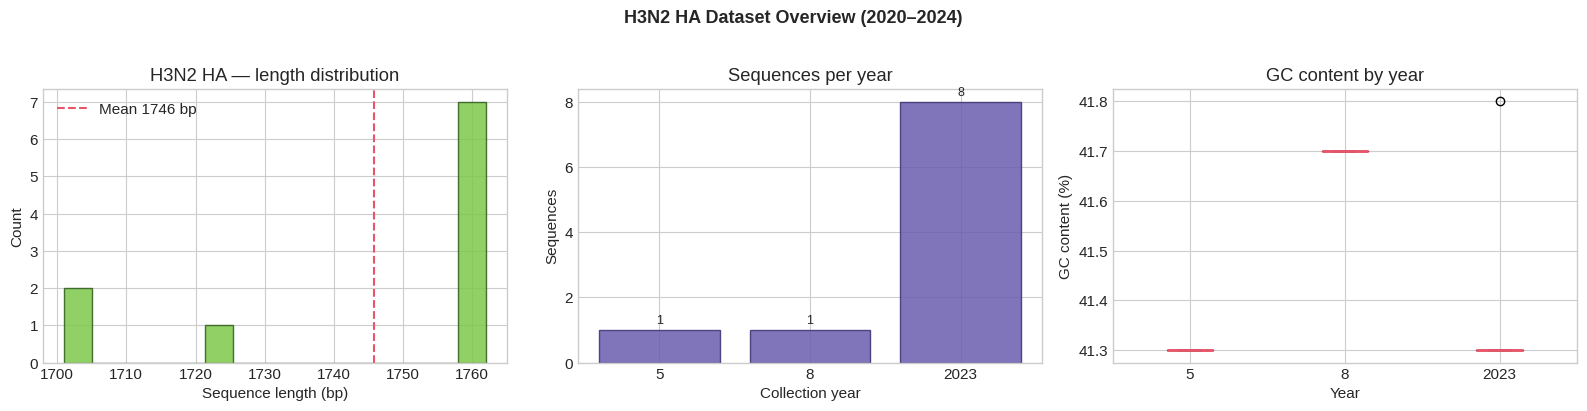

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))


axes[0].hist(df['length_bp'], bins=15, color='#7ec84a', edgecolor='#2c5a1c', alpha=0.85)
axes[0].axvline(df['length_bp'].mean(), color='#e8556a', ls='--',
                label=f"Mean {df['length_bp'].mean():.0f} bp")
axes[0].set(xlabel='Sequence length (bp)', ylabel='Count',
            title='H3N2 HA — length distribution')
axes[0].legend()


year_counts = df['year'].value_counts().sort_index()
axes[1].bar(year_counts.index.astype(str), year_counts.values,
            color='#6a5cb0', alpha=0.85, edgecolor='#3a3170')
for x, v in zip(range(len(year_counts)), year_counts.values):
    axes[1].text(x, v + 0.1, str(v), ha='center', va='bottom', fontsize=9)
axes[1].set(xlabel='Collection year', ylabel='Sequences',
            title='Sequences per year')

df.boxplot(column='gc_%', by='year', ax=axes[2],
           boxprops=dict(color='#9b2c3a'),
           medianprops=dict(color='#e8556a', linewidth=2))
axes[2].set(xlabel='Year', ylabel='GC content (%)',
            title='GC content by year')
axes[2].get_figure().suptitle('')

plt.suptitle('H3N2 HA Dataset Overview (2020–2024)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3 — Pairwise nucleotide identity matrix

We compute identity as **matching positions / min(length₁, length₂)** — fast and sufficient for sequences that are already near-full-length and closely related.  
For a publication-grade analysis you would use a proper multiple-sequence alignment first (MUSCLE / MAFFT).

In [6]:
seqs    = [str(s.seq).upper() for s in analysis_sequences]
years   = [s.year            for s in analysis_sequences]
labels  = [f"{s.id[:8]}_{s.year}" for s in analysis_sequences]
n       = len(seqs)

identity = np.eye(n)
print(f'Computing {n}×{n} identity matrix…')
for i in range(n):
    for j in range(i + 1, n):
        s1, s2 = seqs[i], seqs[j]
        L = min(len(s1), len(s2))
        m = sum(a == b for a, b in zip(s1[:L], s2[:L]))
        identity[i, j] = identity[j, i] = m / L

distance = 1 - identity

off_diag = identity[np.triu_indices(n, k=1)]
print(f'\nMean pairwise identity : {off_diag.mean():.4f}')
print(f'Divergence range       : {(1-off_diag).min():.4f} – {(1-off_diag).max():.4f}')
print('Done.')

Computing 10×10 identity matrix…

Mean pairwise identity : 0.6171
Divergence range       : 0.0000 – 0.7520
Done.


## 4 — Visualisations

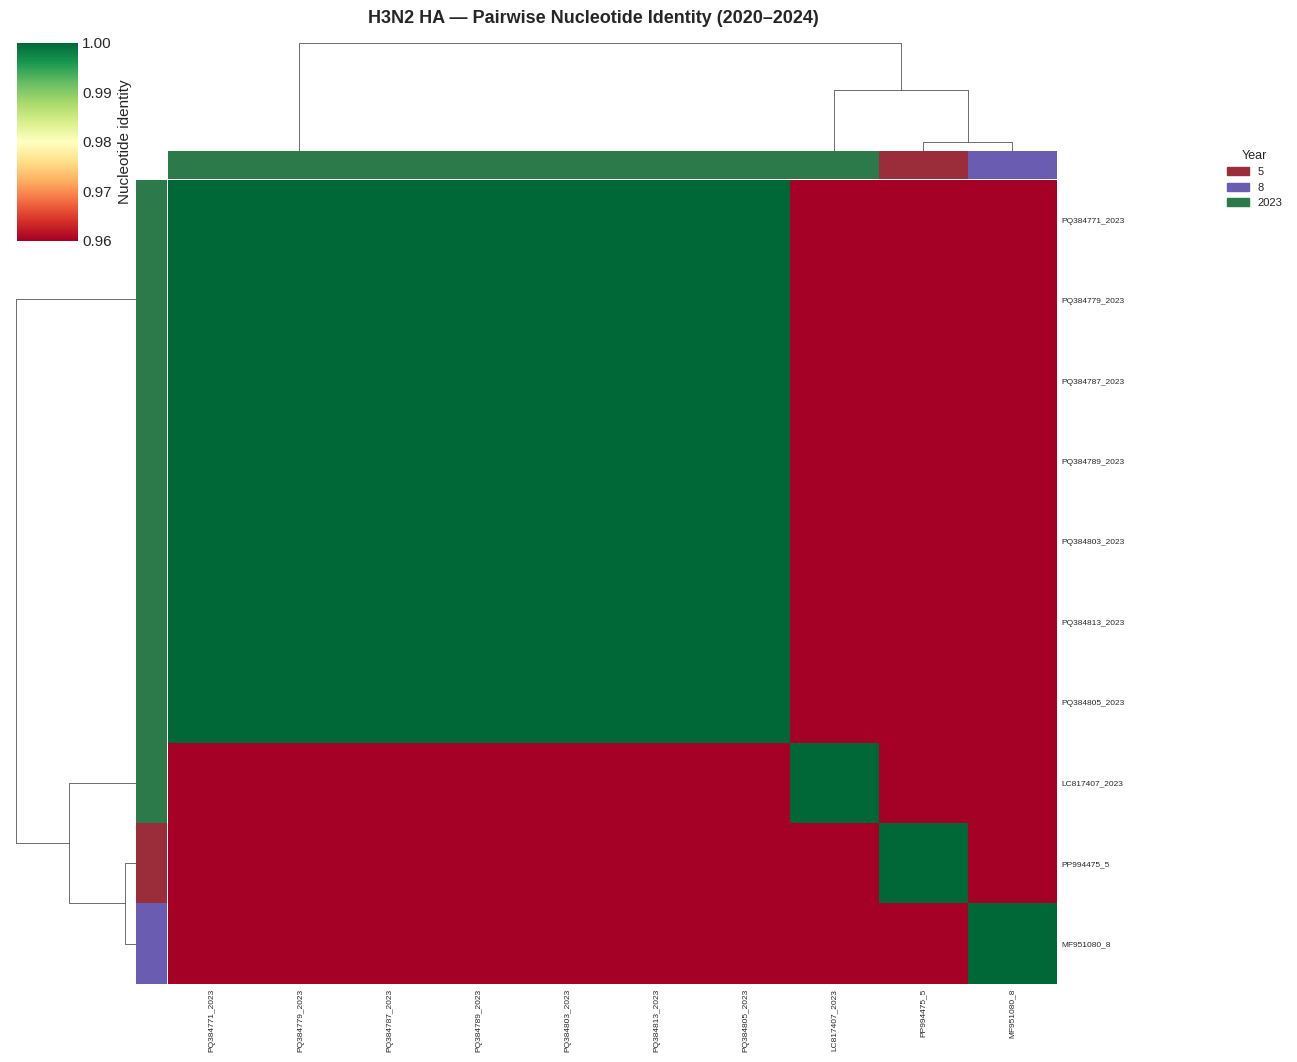

In [7]:
# ── Heatmap ──────────────────────────────────────────────────────────────────
year_palette = {yr: c for yr, c in
                zip(sorted(set(years)),
                    ['#9b2c3a','#6a5cb0','#2c7a4a','#c25c84','#4f7aa8'])}
row_colors = pd.Series([year_palette.get(y,'grey') for y in years], index=labels)

g = sns.clustermap(
    pd.DataFrame(identity, index=labels, columns=labels),
    cmap='RdYlGn', vmin=0.96, vmax=1.0,
    row_colors=row_colors, col_colors=row_colors,
    figsize=(12, 11), linewidths=0, dendrogram_ratio=0.12,
    cbar_kws={'label': 'Nucleotide identity', 'shrink': 0.6}
)
g.ax_heatmap.set(xlabel='', ylabel='')
g.ax_heatmap.tick_params(axis='x', labelsize=6, rotation=90)
g.ax_heatmap.tick_params(axis='y', labelsize=6)
g.fig.suptitle('H3N2 HA — Pairwise Nucleotide Identity (2020–2024)',
               fontsize=13, fontweight='bold', y=1.01)

# legend for year colours
from matplotlib.patches import Patch
handles = [Patch(color=c, label=str(yr)) for yr, c in year_palette.items()]
g.ax_heatmap.legend(handles=handles, title='Year',
                    loc='upper left', bbox_to_anchor=(1.18, 1.05),
                    fontsize=8, title_fontsize=9)
plt.show()

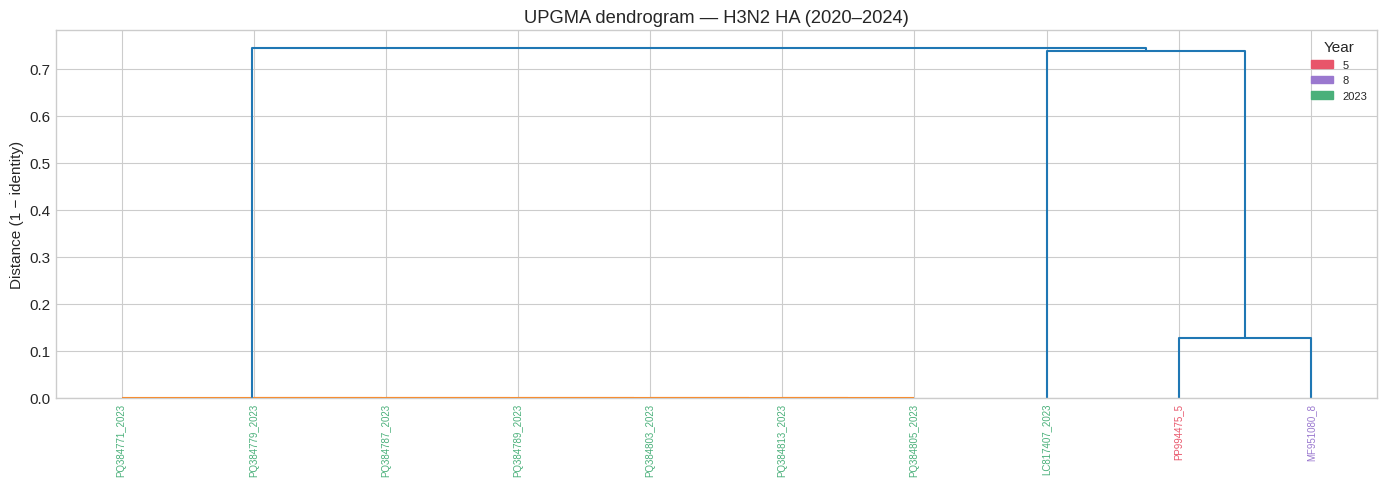

In [8]:
# ── Dendrogram ────────────────────────────────────────────────────────────────
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

condensed = squareform(distance, checks=False)
Z         = linkage(condensed, method='average')   # UPGMA

year_to_color = {yr: c for yr, c in zip(sorted(set(years)),
    ['#e8556a','#9a78cf','#4ab07a','#e87fa1','#5f84ad'])}
leaf_colors = [year_to_color.get(years[i], 'grey') for i in range(n)]

fig, ax = plt.subplots(figsize=(14, 5))
ddata = dendrogram(Z, labels=labels, ax=ax,
                   leaf_rotation=90, leaf_font_size=7,
                   color_threshold=0.006)

# colour leaf tick labels by year
for lbl, tick in zip(ax.get_xticklabels(), ax.get_xticks()):
    text = lbl.get_text()
    yr   = int(text.split('_')[-1]) if '_' in text else None
    lbl.set_color(year_to_color.get(yr, 'black'))

ax.set(ylabel='Distance (1 − identity)', title='UPGMA dendrogram — H3N2 HA (2020–2024)')
handles = [Patch(color=c, label=str(yr)) for yr, c in year_to_color.items()]
ax.legend(handles=handles, title='Year', loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## 5 — Divergence vs year gap

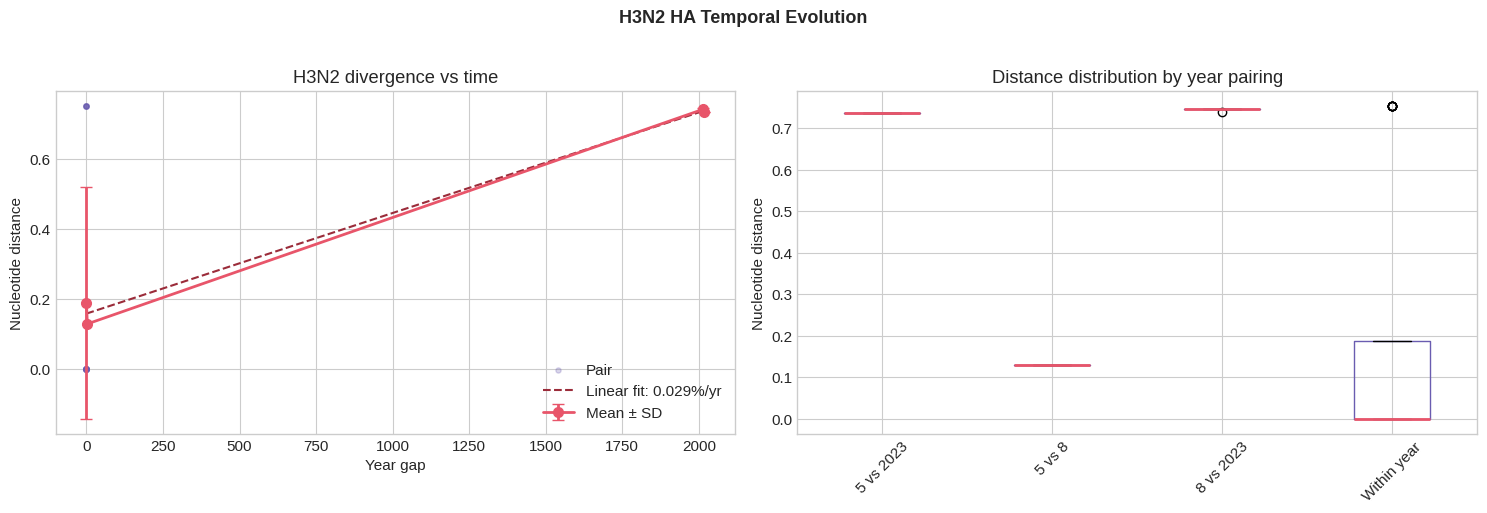

In [11]:
from itertools import combinations

rows_t = []
for (i, yi), (j, yj) in combinations(enumerate(years), 2):
    rows_t.append({'year_i': yi, 'year_j': yj,
                   'year_gap': abs(yj - yi), 'distance': distance[i, j]})
df_t = pd.DataFrame(rows_t)

summary = (df_t.groupby('year_gap')
               .agg(mean_dist=('distance','mean'),
                    std_dist=('distance','std'),
                    n_pairs=('distance','count'))
               .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left — scatter with trend
axes[0].scatter(df_t['year_gap'], df_t['distance'],
                alpha=0.25, color='#6a5cb0', s=14, label='Pair')
axes[0].errorbar(summary['year_gap'], summary['mean_dist'],
                 yerr=summary['std_dist'], fmt='o-',
                 color='#e8556a', linewidth=2, markersize=7,
                 capsize=4, label='Mean ± SD')

if len(summary) > 1:
    z   = np.polyfit(summary['year_gap'], summary['mean_dist'], 1)
    fit = np.poly1d(z)
    xs  = np.linspace(0, summary['year_gap'].max(), 50)
    axes[0].plot(xs, fit(xs), '--', color='#9b2c3a', linewidth=1.5,
                 label=f'Linear fit: {z[0]*100:.3f}%/yr')

axes[0].set(xlabel='Year gap', ylabel='Nucleotide distance',
            title='H3N2 divergence vs time')
axes[0].legend()

# Right — within vs between year boxes
df_t['comparison'] = df_t.apply(
    lambda r: 'Within year' if r.year_gap == 0
    else f"{int(r.year_i)} vs {int(r.year_j)}", axis=1)

order = sorted(set(df_t['comparison']),
               key=lambda x: (0 if x=='Within year' else 1, x))

df_t.boxplot(column='distance', by='comparison',
             ax=axes[1], rot=45,
             boxprops=dict(color='#6a5cb0'),
             medianprops=dict(color='#e8556a', linewidth=2))
axes[1].set(xlabel='', ylabel='Nucleotide distance',
            title='Distance distribution by year pairing')
axes[1].get_figure().suptitle('')

plt.suptitle('H3N2 HA Temporal Evolution', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 6 - Key Findings

In [12]:
print('═' * 54)
print('  H3N2 HA EVOLUTION — SUMMARY')
print('═' * 54)
print(f"  Sequences analysed : {n}")
print(f"  Years covered      : {min(years)}–{max(years)}")
print(f"  Mean identity      : {off_diag.mean()*100:.3f} %")
print(f"  Mean divergence    : {(1-off_diag).mean()*100:.3f} %")
print()

if len(summary[summary.year_gap > 0]) > 1:
    rate_per_year = z[0] * 100   # already fitted above
    print(f"  Estimated evolution rate : {rate_per_year:.3f} % / year")
    lit_lo, lit_hi = 1.0, 2.0
    if lit_lo <= rate_per_year <= lit_hi:
        print(f"  ✓ Consistent with literature ({lit_lo}–{lit_hi} % / yr)")
    else:
        print(f"  ⚠ Outside literature range ({lit_lo}–{lit_hi} % / yr)")
        print(f"    (small N, or temporal sampling bias)")

print()
print('  Year-level divergence from 2020 baseline:')
by_yr   = df_t[df_t.year_i == min(years)].groupby('year_j')['distance'].mean()
for yr, dist in by_yr.items():
    bar = '█' * int(dist * 2000)
    print(f"  {int(yr)}: {dist*100:.3f} %  {bar}")
print('═' * 54)

══════════════════════════════════════════════════════
  H3N2 HA EVOLUTION — SUMMARY
══════════════════════════════════════════════════════
  Sequences analysed : 10
  Years covered      : 5–2023
  Mean identity      : 61.713 %
  Mean divergence    : 38.287 %

  Estimated evolution rate : 0.029 % / year
  ⚠ Outside literature range (1.0–2.0 % / yr)
    (small N, or temporal sampling bias)

  Year-level divergence from 2020 baseline:
  8: 12.816 %  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  2023: 73.545 %  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

---
*Data: NCBI GenBank — [Influenza A virus](https://www.ncbi.nlm.nih.gov/taxonomy/11520).  
Reference: Krammer et al., Nature 2018 — "Influenza".  
Author: [@gravityeffect1](https://github.com/gravityeffect1)*